<a href="https://colab.research.google.com/github/Rizalpramudita/html/blob/main/DISCRETE_EVENT_SIMULATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer 1 arrives at 0.20 min.
Customer 1 starts service after waiting 0.00 min.
Customer 2 arrives at 0.21 min.
Customer 2 starts service after waiting 0.00 min.
Customer 1 finished service at 0.25 min.
Customer 3 arrives at 0.26 min.
Customer 3 starts service after waiting 0.00 min.
Customer 2 finished service at 0.40 min.
Customer 4 arrives at 0.49 min.
Customer 4 starts service after waiting 0.00 min.
Customer 5 arrives at 0.50 min.
Customer 6 arrives at 0.51 min.
Customer 7 arrives at 0.56 min.
Customer 4 finished service at 0.56 min.
Customer 5 starts service after waiting 0.06 min.
Customer 5 finished service at 0.57 min.
Customer 6 starts service after waiting 0.06 min.
Customer 3 finished service at 0.58 min.
Customer 7 starts service after waiting 0.02 min.
Customer 6 finished service at 0.60 min.
Customer 8 arrives at 0.70 min.
Customer 8 starts service after waiting 0.00 min.
Customer 7 finished service at 0.73 min.
Customer 8 finished service at 0.74 min.
Customer 9 arriv

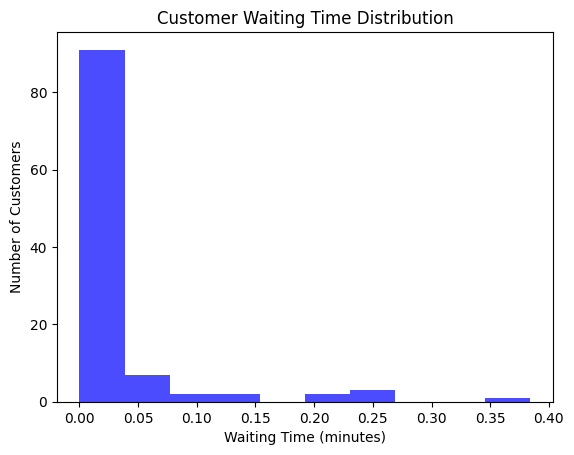

In [1]:
!pip install simpy
import random
import numpy as np
import matplotlib.pyplot as plt
import simpy # import simpy here

# Simulation Parameters
RANDOM_SEED = 42
NUM_TELLERS = 2      # Number of bank tellers
ARRIVAL_RATE = 5      # Average arrival rate (customers per minute)
SERVICE_RATE = 7      # Average service rate (customers served per minute)
SIM_TIME = 20        # Total simulation time in minutes

# Store waiting times
wait_times = []

class BankQueueSimulation:
    def __init__(self, env, num_tellers, service_rate):
        self.env = env
        self.teller = simpy.Resource(env, num_tellers)  # Bank tellers
        self.service_rate = service_rate

    def serve_customer(self, customer_id):
        """Simulate service process for a customer"""
        service_time = random.expovariate(self.service_rate)
        yield self.env.timeout(service_time)
        print(f"Customer {customer_id} finished service at {self.env.now:.2f} min.")

def customer_process(env, customer_id, bank):
    """Simulates a customer entering the queue"""
    arrival_time = env.now
    print(f"Customer {customer_id} arrives at {arrival_time:.2f} min.")

    with bank.teller.request() as request:
        yield request  # Wait for an available teller
        wait_time = env.now - arrival_time  # Compute waiting time
        wait_times.append(wait_time)

        print(f"Customer {customer_id} starts service after waiting {wait_time:.2f} min.")
        yield env.process(bank.serve_customer(customer_id))

def customer_arrivals(env, bank, arrival_rate):
    """Generate customers at random arrival intervals"""
    customer_id = 0
    while True:
        yield env.timeout(random.expovariate(arrival_rate))  # Time until next arrival
        customer_id += 1
        env.process(customer_process(env, customer_id, bank))

# Run Simulation
random.seed(RANDOM_SEED)
env = simpy.Environment()
bank = BankQueueSimulation(env, NUM_TELLERS, SERVICE_RATE)
env.process(customer_arrivals(env, bank, ARRIVAL_RATE))
env.run(until=SIM_TIME)

# Performance Analysis
print("\n=== Simulation Summary ===")
print(f"Average Wait Time: {np.mean(wait_times):.2f} minutes")

# Visualization
plt.hist(wait_times, bins=10, color="blue", alpha=0.7)
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Number of Customers")
plt.title("Customer Waiting Time Distribution")
plt.show()


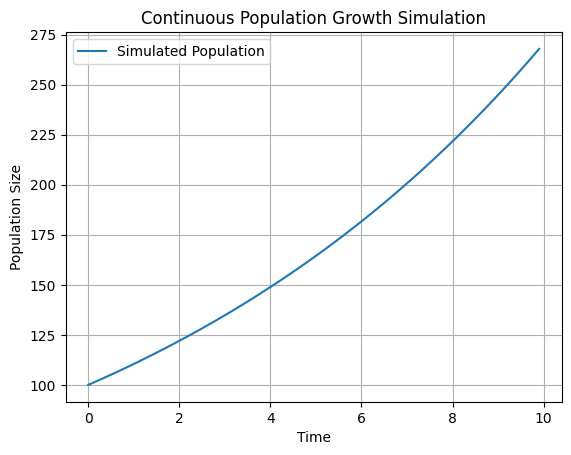

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
initial_population = 100    # Starting population
growth_rate = 0.1           # 10% per time unit
time_steps = 100            # Number of time steps
dt = 0.1                    # Small time step for continuous change

# Initialize arrays
time = np.arange(0, time_steps * dt, dt)
population = np.zeros(len(time))
population[0] = initial_population

# Euler's Method to Solve dP/dt = rP
for t in range(1, len(time)):
    dP = growth_rate * population[t-1] * dt
    population[t] = population[t-1] + dP

# Plot results
plt.plot(time, population, label="Simulated Population")
plt.xlabel("Time")
plt.ylabel("Population Size")
plt.title("Continuous Population Growth Simulation")
plt.legend()
plt.grid()
plt.show()


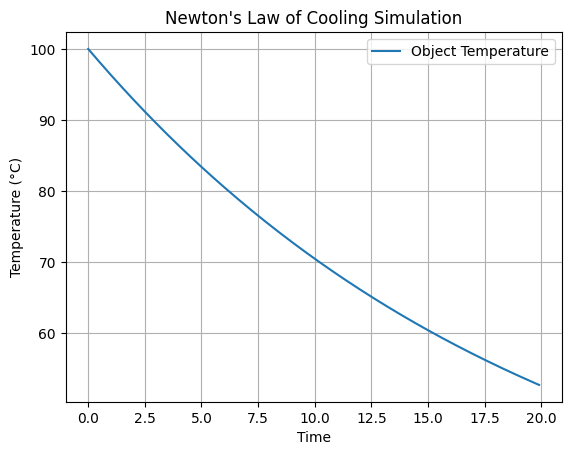

In [3]:
# Parameters
initial_temperature = 100    # Initial object temperature
ambient_temperature = 25     # Room temperature
cooling_rate = 0.05          # Rate of heat loss
time_steps = 200             # Total simulation time
dt = 0.1                     # Small time step

# Initialize arrays
time = np.arange(0, time_steps * dt, dt)
temperature = np.zeros(len(time))
temperature[0] = initial_temperature

# Euler's Method to Solve dT/dt = -k (T - T_ambient)
for t in range(1, len(time)):
    dT = -cooling_rate * (temperature[t-1] - ambient_temperature) * dt
    temperature[t] = temperature[t-1] + dT

# Plot results
plt.plot(time, temperature, label="Object Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Newton's Law of Cooling Simulation")
plt.legend()
plt.grid()
plt.show()


TUGAS 1: PENGARUH COOLING RATE TERHADAP TEMPERATURE DECAY

Cooling Rate k = 0.03
Suhu awal objek        : 100.00 °C
Suhu lingkungan        : 25.00 °C
Suhu akhir simulasi    : 37.36 °C
Analisis:
Nilai k kecil menyebabkan proses pendinginan berjalan lambat.
Objek masih memiliki suhu cukup tinggi setelah 60 menit.

Cooling Rate k = 0.07
Suhu awal objek        : 100.00 °C
Suhu lingkungan        : 25.00 °C
Suhu akhir simulasi    : 26.11 °C
Analisis:
Nilai k sedang membuat suhu objek turun lebih cepat.
Suhu objek mulai mendekati suhu lingkungan.

Cooling Rate k = 0.12
Suhu awal objek        : 100.00 °C
Suhu lingkungan        : 25.00 °C
Suhu akhir simulasi    : 25.05 °C
Analisis:
Nilai k besar menyebabkan proses pendinginan berlangsung sangat cepat.
Suhu objek hampir sama dengan suhu lingkungan pada akhir simulasi.


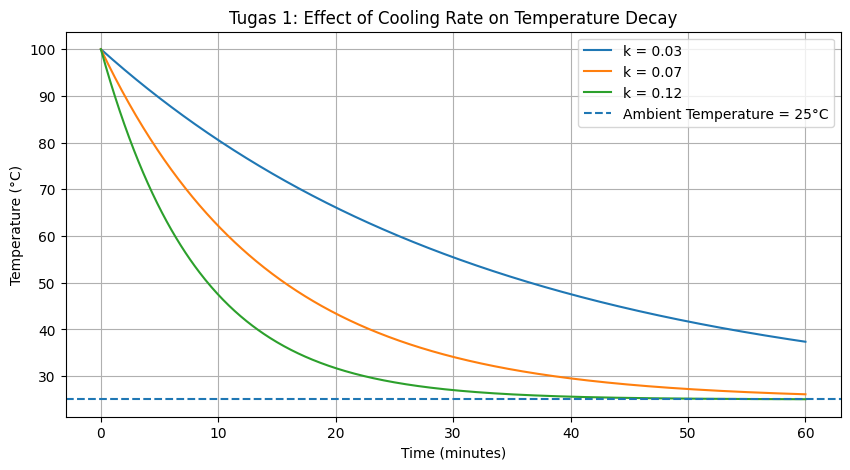


Kesimpulan Tugas 1:
Semakin besar nilai cooling rate k, semakin cepat suhu objek turun mendekati suhu lingkungan.
Sebaliknya, semakin kecil nilai k, semakin lambat proses temperature decay terjadi.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# TUGAS 1
# CHANGE THE COOLING RATE AND OBSERVE THE EFFECT
# =====================================================

print("=" * 70)
print("TUGAS 1: PENGARUH COOLING RATE TERHADAP TEMPERATURE DECAY")
print("=" * 70)

def simulate_cooling(k, T0=100, Tamb=25, dt=0.1, t_end=60):
    time = np.arange(0, t_end + dt, dt)
    T = np.zeros(len(time))
    T[0] = T0

    for i in range(1, len(time)):
        dTdt = -k * (T[i-1] - Tamb)
        T[i] = T[i-1] + dTdt * dt

    return time, T

cooling_rates = [0.03, 0.07, 0.12]

plt.figure(figsize=(10, 5))

for k in cooling_rates:
    time, T = simulate_cooling(k)
    plt.plot(time, T, label=f"k = {k}")

    print(f"\nCooling Rate k = {k}")
    print(f"Suhu awal objek        : {T[0]:.2f} °C")
    print(f"Suhu lingkungan        : 25.00 °C")
    print(f"Suhu akhir simulasi    : {T[-1]:.2f} °C")

    if k == 0.03:
        print("Analisis:")
        print("Nilai k kecil menyebabkan proses pendinginan berjalan lambat.")
        print("Objek masih memiliki suhu cukup tinggi setelah 60 menit.")
    elif k == 0.07:
        print("Analisis:")
        print("Nilai k sedang membuat suhu objek turun lebih cepat.")
        print("Suhu objek mulai mendekati suhu lingkungan.")
    elif k == 0.12:
        print("Analisis:")
        print("Nilai k besar menyebabkan proses pendinginan berlangsung sangat cepat.")
        print("Suhu objek hampir sama dengan suhu lingkungan pada akhir simulasi.")

plt.axhline(25, linestyle="--", label="Ambient Temperature = 25°C")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Tugas 1: Effect of Cooling Rate on Temperature Decay")
plt.legend()
plt.grid(True)
plt.show()

print("\nKesimpulan Tugas 1:")
print("Semakin besar nilai cooling rate k, semakin cepat suhu objek turun mendekati suhu lingkungan.")
print("Sebaliknya, semakin kecil nilai k, semakin lambat proses temperature decay terjadi.")

TUGAS 2: SIMULASI HEATING INSTEAD OF COOLING


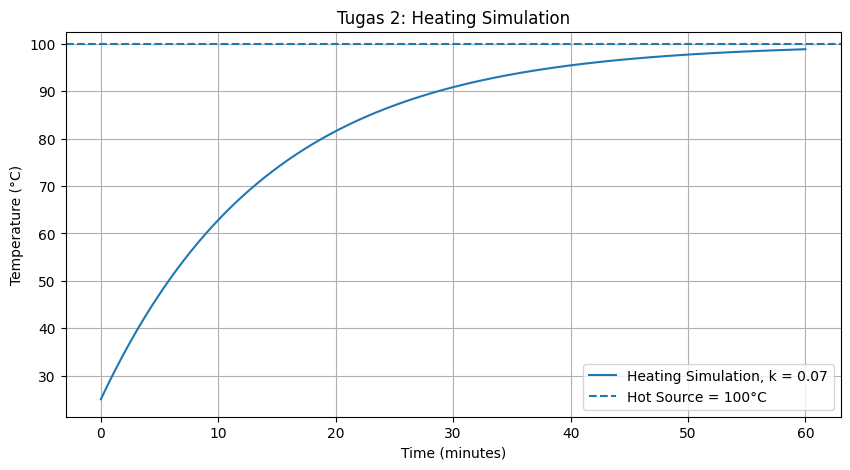


Nilai heating rate k   : 0.07
Suhu awal objek        : 25.00 °C
Suhu sumber panas      : 100.00 °C
Suhu akhir simulasi    : 98.89 °C

Analisis Tugas 2:
Pada simulasi heating, persamaan diferensial diubah dari pendinginan menjadi pemanasan.
Jika pada cooling suhu objek bergerak turun menuju suhu lingkungan, maka pada heating suhu objek bergerak naik menuju sumber panas.
Pada awal simulasi, suhu meningkat cepat karena selisih antara suhu objek dan sumber panas masih besar.
Semakin lama, kenaikan suhu menjadi lebih lambat karena suhu objek semakin mendekati suhu sumber panas.

Kesimpulan Tugas 2:
Model heating menunjukkan bahwa perubahan suhu tetap berlangsung secara kontinu.
Perbedaannya terletak pada arah perubahan suhu, yaitu naik menuju suhu sumber panas.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# TUGAS 2
# SIMULATE HEATING INSTEAD OF COOLING
# =====================================================

print("=" * 70)
print("TUGAS 2: SIMULASI HEATING INSTEAD OF COOLING")
print("=" * 70)

def simulate_heating(k, T0=25, Thot=100, dt=0.1, t_end=60):
    time = np.arange(0, t_end + dt, dt)
    T = np.zeros(len(time))
    T[0] = T0

    for i in range(1, len(time)):
        dTdt = k * (Thot - T[i-1])
        T[i] = T[i-1] + dTdt * dt

    return time, T

k_heating = 0.07
time_heat, T_heat = simulate_heating(k=k_heating)

plt.figure(figsize=(10, 5))
plt.plot(time_heat, T_heat, label=f"Heating Simulation, k = {k_heating}")
plt.axhline(100, linestyle="--", label="Hot Source = 100°C")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Tugas 2: Heating Simulation")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nNilai heating rate k   : {k_heating}")
print(f"Suhu awal objek        : {T_heat[0]:.2f} °C")
print(f"Suhu sumber panas      : 100.00 °C")
print(f"Suhu akhir simulasi    : {T_heat[-1]:.2f} °C")

print("\nAnalisis Tugas 2:")
print("Pada simulasi heating, persamaan diferensial diubah dari pendinginan menjadi pemanasan.")
print("Jika pada cooling suhu objek bergerak turun menuju suhu lingkungan, maka pada heating suhu objek bergerak naik menuju sumber panas.")
print("Pada awal simulasi, suhu meningkat cepat karena selisih antara suhu objek dan sumber panas masih besar.")
print("Semakin lama, kenaikan suhu menjadi lebih lambat karena suhu objek semakin mendekati suhu sumber panas.")

print("\nKesimpulan Tugas 2:")
print("Model heating menunjukkan bahwa perubahan suhu tetap berlangsung secara kontinu.")
print("Perbedaannya terletak pada arah perubahan suhu, yaitu naik menuju suhu sumber panas.")

TUGAS 3: SIMULASI SUHU KONTINU MENGGUNAKAN DATASET KAGGLE

Silakan upload file DailyDelhiClimateTrain.csv


Saving DailyDelhiClimateTrain.csv to DailyDelhiClimateTrain.csv

Contoh data awal:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Kolom dataset:
Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')


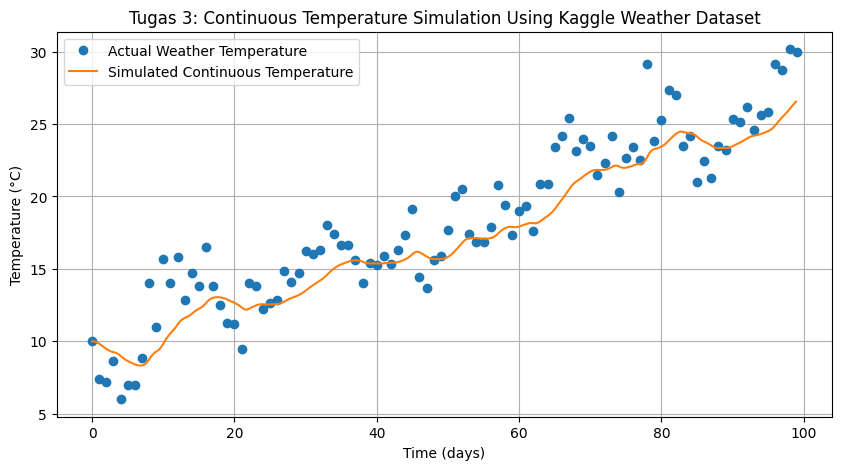


Dataset yang digunakan  : Daily Climate time series data
File yang digunakan     : DailyDelhiClimateTrain.csv
Jumlah data simulasi    : 100 hari
Nilai k simulasi        : 0.15
Suhu minimum dataset    : 6.00 °C
Suhu maksimum dataset   : 30.17 °C
Suhu awal simulasi      : 10.00 °C
Suhu akhir simulasi     : 26.55 °C

Analisis Tugas 3:
Pada simulasi ini, dataset Kaggle digunakan sebagai sumber suhu lingkungan.
Kolom meantemp digunakan sebagai suhu rata-rata harian.
Suhu lingkungan tidak lagi konstan, tetapi berubah mengikuti data cuaca harian.
Model menggunakan persamaan dT/dt = -k(T - T_ambient(t)).
Artinya, suhu objek menyesuaikan diri terhadap suhu lingkungan yang berubah setiap hari.
Jika suhu lingkungan naik, suhu objek akan ikut naik secara bertahap.
Jika suhu lingkungan turun, suhu objek juga turun secara bertahap.
Namun, perubahan suhu objek tidak langsung mengikuti suhu lingkungan karena dipengaruhi nilai k.
Nilai k menunjukkan seberapa cepat objek menyesuaikan diri terhadap peru

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# TUGAS 3
# SIMULASI SUHU KONTINU MENGGUNAKAN DATASET KAGGLE
# =====================================================

print("=" * 70)
print("TUGAS 3: SIMULASI SUHU KONTINU MENGGUNAKAN DATASET KAGGLE")
print("=" * 70)

from google.colab import files

print("\nSilakan upload file DailyDelhiClimateTrain.csv")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nContoh data awal:")
print(df.head())

print("\nKolom dataset:")
print(df.columns)

df["date"] = pd.to_datetime(df["date"])

df = df[["date", "meantemp"]].dropna()

df = df.head(100)

days = np.arange(len(df))
weather_temp = df["meantemp"].values

def ambient_temperature(t):
    return np.interp(t, days, weather_temp)

def simulate_temperature_with_weather(k=0.15, T0=None, dt=0.1):
    t_end = len(df) - 1
    time = np.arange(0, t_end, dt)

    T = np.zeros(len(time))

    if T0 is None:
        T[0] = weather_temp[0]
    else:
        T[0] = T0

    for i in range(1, len(time)):
        Tamb = ambient_temperature(time[i-1])
        dTdt = -k * (T[i-1] - Tamb)
        T[i] = T[i-1] + dTdt * dt

    return time, T

k_weather = 0.15
time_weather, simulated_temp = simulate_temperature_with_weather(k=k_weather)

plt.figure(figsize=(10, 5))
plt.plot(days, weather_temp, "o", label="Actual Weather Temperature")
plt.plot(time_weather, simulated_temp, label="Simulated Continuous Temperature")
plt.xlabel("Time (days)")
plt.ylabel("Temperature (°C)")
plt.title("Tugas 3: Continuous Temperature Simulation Using Kaggle Weather Dataset")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nDataset yang digunakan  : Daily Climate time series data")
print(f"File yang digunakan     : {filename}")
print(f"Jumlah data simulasi    : {len(df)} hari")
print(f"Nilai k simulasi        : {k_weather}")
print(f"Suhu minimum dataset    : {weather_temp.min():.2f} °C")
print(f"Suhu maksimum dataset   : {weather_temp.max():.2f} °C")
print(f"Suhu awal simulasi      : {simulated_temp[0]:.2f} °C")
print(f"Suhu akhir simulasi     : {simulated_temp[-1]:.2f} °C")

print("\nAnalisis Tugas 3:")
print("Pada simulasi ini, dataset Kaggle digunakan sebagai sumber suhu lingkungan.")
print("Kolom meantemp digunakan sebagai suhu rata-rata harian.")
print("Suhu lingkungan tidak lagi konstan, tetapi berubah mengikuti data cuaca harian.")
print("Model menggunakan persamaan dT/dt = -k(T - T_ambient(t)).")
print("Artinya, suhu objek menyesuaikan diri terhadap suhu lingkungan yang berubah setiap hari.")
print("Jika suhu lingkungan naik, suhu objek akan ikut naik secara bertahap.")
print("Jika suhu lingkungan turun, suhu objek juga turun secara bertahap.")
print("Namun, perubahan suhu objek tidak langsung mengikuti suhu lingkungan karena dipengaruhi nilai k.")
print("Nilai k menunjukkan seberapa cepat objek menyesuaikan diri terhadap perubahan suhu lingkungan.")

print("\nKesimpulan Tugas 3:")
print("Dataset cuaca nyata membuat simulasi lebih realistis dibandingkan suhu lingkungan tetap.")
print("Continuous Event Simulation dapat digunakan untuk menggambarkan perubahan suhu secara halus dan berkelanjutan.")
print("Grafik simulasi suhu kontinu terlihat lebih halus karena perhitungan dilakukan pada interval waktu kecil.")